In [39]:
import mujoco
import mujoco.viewer
import time
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import deque
import numpy as np

# Helper function to bring window to foreground on Windows
def bring_window_to_foreground():
    """Bring the MuJoCo viewer window to the foreground (Windows only)"""
    if sys.platform == 'win32':
        import ctypes
        import subprocess
        
        try:
            # Method 1: Try using subprocess to activate the last created window
            # This is more reliable than direct ctypes calls
            subprocess.Popen("powershell -Command \"[Windows.System.Launcher]::LaunchUriAsync('ms-settings:') | Out-Null; Start-Sleep -Milliseconds 100\"", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            time.sleep(0.1)
            
            # Method 2: Try to find and activate any GLFW window (MuJoCo uses GLFW)
            hwnd = ctypes.windll.user32.FindWindowW(ctypes.c_wchar_p("GLFW30"), None)
            if hwnd:
                ctypes.windll.user32.SetForegroundWindow(hwnd)
                time.sleep(0.1)
                return
            
            # Method 3: Use keyboard shortcut to switch windows (Alt+Tab alternative)
            ctypes.windll.user32.keybd_event(0xA4, 0, 0, 0)  # Alt down
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0x09, 0, 0, 0)  # Tab down
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0x09, 0, 0x2, 0)  # Tab up
            time.sleep(0.05)
            ctypes.windll.user32.keybd_event(0xA4, 0, 0x2, 0)  # Alt up
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Could not bring window to foreground: {e}")

# Load the Segway model
script_dir = os.getcwd()
if not os.path.exists(os.path.join(script_dir, "segway_2.xml")):
    script_dir = os.path.join(script_dir, "Ozzy")

model = mujoco.MjModel.from_xml_path(os.path.join(script_dir, "segway_2.xml"))
data = mujoco.MjData(model)

# Understanding qpos and qvel:
# The segway body has a <freejoint> which creates 6 DOFs (floating base):
#   qpos[0:3] = [x, y, z] position
#   qpos[3:7] = [qw, qx, qy, qz] quaternion (orientation)
# Additional joints in the model:
#   qpos[7] = ground wheel angle
#   qpos[8] = reaction wheel angle
#
# Similarly for velocity:
#   qvel[0:3] = linear velocities [vx, vy, vz]
#   qvel[3:6] = angular velocities [wx, wy, wz]
#   qvel[6] = ground wheel angular velocity
#   qvel[7] = reaction wheel angular velocity

# Set initial conditions
data.qpos[0] = 0.0      # x position
data.qpos[1] = 0.0      # y position  
data.qpos[2] = 0.1      # z position
# Keep default quaternion (identity) for now

data.qvel[:] = 0.0      # All velocities start at zero

# Tilt the Segway forward by rotating around y-axis by 0.1 rad
# Rotation.from_euler() creates a rotation object from Euler angles:
#   - 'y' specifies rotation around the Y-axis
#   - 0.1 is the rotation angle in radians (≈5.7 degrees)
rot = Rotation.from_euler('y', 0.1)
# Convert the rotation to quaternion format: returns [qx, qy, qz, qw]
# (Note: this is the standard scipy format: x, y, z, w components)
quat = rot.as_quat()
# MuJoCo expects quaternions in [qw, qx, qy, qz] format, so we reorder:
# scipy's [qx, qy, qz, qw] → MuJoCo's [qw, qx, qy, qz]
data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]

mujoco.mj_forward(model, data)

# PID Controller Parameters (tuned for reaction wheel control)
Kp = 100.0   # Proportional gain for angle error
Kd = 3.0     # Derivative gain for angular velocity damping
Ki = 0.5     # Integral gain for steady-state error

# Velocity Controller Parameters
Kp_v = 5.0  # Proportional gain for velocity error
Kd_v = 0.10   # Derivative gain for acceleration feedback
v_desired = -0.0  # Desired forward velocity in m/s

dt = model.opt.timestep

print(f"Model loaded successfully!")
print(f"Simulation timestep: {dt} seconds")
print(f"Model structure:")
print(f"  - Free joint (body orientation): qpos[3:7] (quaternion)")
print(f"  - Ground wheel joint: qpos[7]")
print(f"  - Reaction wheel joint: qpos[8]")
print(f"\nControl actuators:")
print(f"  - ctrl[0]: Ground wheel motor (ctrlrange: -1 to 1)")
print(f"  - ctrl[1]: Reaction wheel motor (ctrlrange: -5 to 5)")
print(f"\nAngle PID Controller - Kp: {Kp}, Ki: {Ki}, Kd: {Kd}")
print(f"Velocity Controller - Kp: {Kp_v}, Kd: {Kd_v}")
print(f"Desired velocity: {v_desired} m/s")


Model loaded successfully!
Simulation timestep: 0.002 seconds
Model structure:
  - Free joint (body orientation): qpos[3:7] (quaternion)
  - Ground wheel joint: qpos[7]
  - Reaction wheel joint: qpos[8]

Control actuators:
  - ctrl[0]: Ground wheel motor (ctrlrange: -1 to 1)
  - ctrl[1]: Reaction wheel motor (ctrlrange: -5 to 5)

Angle PID Controller - Kp: 100.0, Ki: 0.5, Kd: 3.0
Velocity Controller - Kp: 5.0, Kd: 0.1
Desired velocity: -0.0 m/s


In [33]:
# Run simulation for 8 seconds with visualization, collecting data
simulation_time = 18.0
time_elapsed = 0.0
integral_error = 0.0
prev_velocity = 0.0  # For computing acceleration

# Storage arrays for plotting
times = []
x_positions = []
angles = []
x_velocities = []
angle_velocities = []
control_inputs_angle = []
control_inputs_velocity = []
control_inputs_total = []

# Reset to initial conditions
data.qpos[0] = 0.0
data.qpos[1] = 0.0
data.qpos[2] = 0.1
rot = Rotation.from_euler('y', 0.1)
quat = rot.as_quat()
data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]

data.qvel[:] = 0.0
mujoco.mj_forward(model, data)

print(f"Running simulation for {simulation_time} seconds...")
print(f"Note: Using reaction wheel motor (joint_reaction_wheel) for control")
print(f"MuJoCo viewer will pop up as active window")

# Launch the MuJoCo viewer
with mujoco.viewer.launch_passive(model, data) as viewer:
    # Bring the viewer window to the foreground immediately
    bring_window_to_foreground()
    
    while time_elapsed < simulation_time and viewer.is_running():
        # Extract angle from vertical from the quaternion
        quat = data.qpos[3:7]  # [qw, qx, qy, qz]
        rot = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
        euler_angles = rot.as_euler('xyz')
        theta = euler_angles[1]  # Pitch angle
        
        # Angular velocity (pitch rate)
        theta_dot = data.qvel[4]  # wy is pitch rate
        
        # Horizontal velocity
        x_dot = data.qvel[0]
        
        # ============ ANGLE CONTROLLER ============
        # Error in angle (we want theta = 0 for upright position)
        angle_error = theta
        
        # Accumulate integral error
        integral_error += angle_error * dt
        
        # PID control law for angle stabilization
        u_angle = Kp * angle_error + Ki * integral_error + Kd * theta_dot
        
        # ============ VELOCITY CONTROLLER ============
        # Error in velocity (difference from desired velocity)
        velocity_error = v_desired - x_dot
        
        # Approximate acceleration (derivative of velocity)
        acceleration = (x_dot - prev_velocity) / dt
        
        # Control law for velocity tracking
        # This will adjust motor torque to accelerate/decelerate toward desired velocity
        u_velocity = Kp_v * velocity_error - Kd_v * acceleration
        
        # ============ COMBINED CONTROL ============
        # The two controllers work together:
        # - Angle controller maintains balance (angle ≈ 0)
        # - Velocity controller drives forward/backward
        # - When velocity is low, velocity controller tilts Segway forward
        # - When tilt gets too large, angle controller resists to maintain balance
        # This creates a natural balance while moving toward desired velocity
        u_total = u_angle - u_velocity*0
        
        # Saturate force within motor limits (ctrlrange="-5 5" for reaction wheel)
        u_total = max(min(u_total, 5.0), -5.0)
        
        # Apply control to REACTION WHEEL motor (ctrl[1])
        data.ctrl[0] = -u_total
        
        # Collect data
        times.append(time_elapsed)
        x_positions.append(data.qpos[0])
        angles.append(theta)
        x_velocities.append(x_dot)
        angle_velocities.append(theta_dot)
        control_inputs_angle.append(u_angle)
        control_inputs_velocity.append(u_velocity)
        control_inputs_total.append(u_total)
        
        # Update previous velocity for next iteration
        prev_velocity = x_dot
        
        # Step simulation
        time.sleep(dt)
        mujoco.mj_step(model, data)
        viewer.sync()  # Sync viewer with simulation state
        
        time_elapsed += dt

print(f"Simulation complete! Collected {len(times)} data points.")
print(f"Final angle: {angles[-1]:.3f} rad")
print(f"Final position: {x_positions[-1]:.3f} m")
print(f"Final velocity: {x_velocities[-1]:.3f} m/s")
print(f"Desired velocity: {v_desired:.3f} m/s")


Running simulation for 18.0 seconds...
Note: Using reaction wheel motor (joint_reaction_wheel) for control
MuJoCo viewer will pop up as active window
Simulation complete! Collected 3318 data points.
Final angle: 0.000 rad
Final position: 0.135 m
Final velocity: 0.020 m/s
Desired velocity: -0.000 m/s


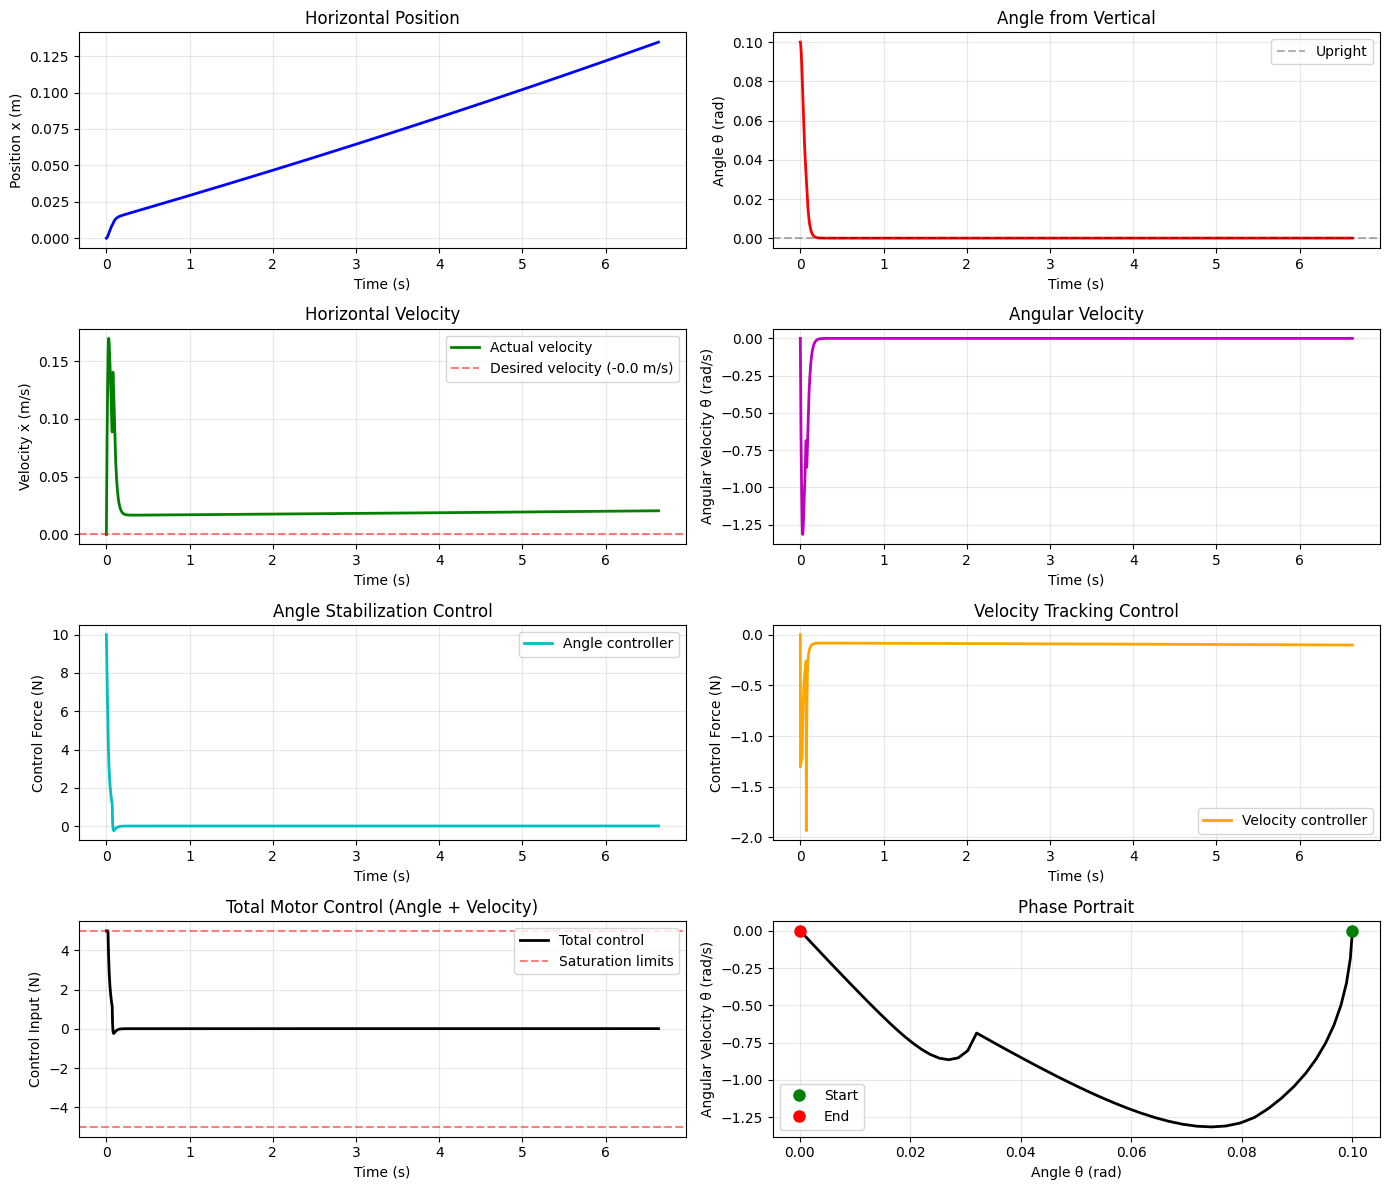


Simulation Summary:
  Max angle deviation: 0.100 rad
  Final angle: 0.000 rad
  Total distance traveled: 0.135 m
  Final velocity: 0.020 m/s
  Desired velocity: -0.000 m/s
  Max control force used: 5.0 N

Controller Contributions (average magnitude):
  Angle control: 0.06 N
  Velocity control: 0.10 N


In [34]:
# Plot states and control inputs over time
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

# Plot 1: Position vs Time
axes[0, 0].plot(times, x_positions, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Position x (m)')
axes[0, 0].set_title('Horizontal Position')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Angle vs Time
axes[0, 1].plot(times, angles, 'r-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3, label='Upright')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angle θ (rad)')
axes[0, 1].set_title('Angle from Vertical')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Horizontal Velocity vs Time
axes[1, 0].plot(times, x_velocities, 'g-', linewidth=2, label='Actual velocity')
axes[1, 0].axhline(y=v_desired, color='r', linestyle='--', alpha=0.5, label=f'Desired velocity ({v_desired} m/s)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Velocity ẋ (m/s)')
axes[1, 0].set_title('Horizontal Velocity')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Angular Velocity vs Time
axes[1, 1].plot(times, angle_velocities, 'm-', linewidth=2)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Angular Velocity θ̇ (rad/s)')
axes[1, 1].set_title('Angular Velocity')
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Angle Control Input vs Time
axes[2, 0].plot(times, control_inputs_angle, 'c-', linewidth=2, label='Angle controller')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Control Force (N)')
axes[2, 0].set_title('Angle Stabilization Control')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

# Plot 6: Velocity Control Input vs Time
axes[2, 1].plot(times, control_inputs_velocity, 'orange', linewidth=2, label='Velocity controller')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Control Force (N)')
axes[2, 1].set_title('Velocity Tracking Control')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

# Plot 7: Total Control Input vs Time
axes[3, 0].plot(times, control_inputs_total, 'k-', linewidth=2, label='Total control')
axes[3, 0].axhline(y=5.0, color='r', linestyle='--', alpha=0.5, label='Saturation limits')
axes[3, 0].axhline(y=-5.0, color='r', linestyle='--', alpha=0.5)
axes[3, 0].set_xlabel('Time (s)')
axes[3, 0].set_ylabel('Control Input (N)')
axes[3, 0].set_title('Total Motor Control (Angle + Velocity)')
axes[3, 0].grid(True, alpha=0.3)
axes[3, 0].legend()

# Plot 8: Phase Portrait (Angle vs Angular Velocity)
axes[3, 1].plot(angles, angle_velocities, 'k-', linewidth=2)
axes[3, 1].plot(angles[0], angle_velocities[0], 'go', markersize=8, label='Start')
axes[3, 1].plot(angles[-1], angle_velocities[-1], 'ro', markersize=8, label='End')
axes[3, 1].set_xlabel('Angle θ (rad)')
axes[3, 1].set_ylabel('Angular Velocity θ̇ (rad/s)')
axes[3, 1].set_title('Phase Portrait')
axes[3, 1].grid(True, alpha=0.3)
axes[3, 1].legend()

plt.tight_layout()
plt.show()

print("\nSimulation Summary:")
print(f"  Max angle deviation: {max(abs(a) for a in angles):.3f} rad")
print(f"  Final angle: {angles[-1]:.3f} rad")
print(f"  Total distance traveled: {x_positions[-1]:.3f} m")
print(f"  Final velocity: {x_velocities[-1]:.3f} m/s")
print(f"  Desired velocity: {v_desired:.3f} m/s")
print(f"  Max control force used: {max(abs(u) for u in control_inputs_total):.1f} N")
print(f"\nController Contributions (average magnitude):")
print(f"  Angle control: {np.mean(np.abs(control_inputs_angle)):.2f} N")
print(f"  Velocity control: {np.mean(np.abs(control_inputs_velocity)):.2f} N")


In [41]:
# ============ ACTOR-CRITIC REINFORCEMENT LEARNING MODEL ============
# This model learns to balance the segway at the upright position using
# advantage actor-critic (A2C) algorithm

class ActorCriticModel(keras.Model):
    """Actor-Critic network for segway balance control"""
    def __init__(self, state_size=3, action_size=1, max_action=5.0):
        super(ActorCriticModel, self).__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.max_action = max_action
        
        # Shared layers
        self.dense1 = layers.Dense(128, activation='relu')
        self.dense2 = layers.Dense(128, activation='relu')
        
        # Actor head - outputs action mean and log std
        self.actor_mean = layers.Dense(action_size, activation='tanh')
        self.actor_logstd = layers.Dense(action_size)
        
        # Critic head - outputs value estimate
        self.critic = layers.Dense(1)
        
    def call(self, state):
        """Forward pass returning mean action, log std, and value"""
        x = self.dense1(state)
        x = self.dense2(x)
        
        # Actor outputs (with tanh squashing)
        mu = self.actor_mean(x)
        logstd = self.actor_logstd(x)
        
        # Critic output
        value = self.critic(x)
        
        return mu, logstd, value
    
    def get_action(self, state, training=False):
        """Sample action from policy"""
        state = tf.expand_dims(state, 0)
        mu, logstd, _ = self(state, training=training)
        
        if training:
            # Reparameterization trick: a = mu + std * epsilon
            std = tf.exp(logstd)
            noise = tf.random.normal(shape=tf.shape(mu))
            action = mu + std * noise
        else:
            action = mu  # Deterministic at test time
        
        # Scale to action bounds
        action = action * self.max_action
        return tf.squeeze(action)

class SegwayEnvironment:
    """Wrapper for segway simulation as RL environment"""
    def __init__(self, model, data, dt, max_steps=500):
        self.model = model
        self.data = data
        self.dt = dt
        self.max_steps = max_steps
        self.steps = 0
        self.initial_qpos = data.qpos.copy()
        self.initial_qvel = data.qvel.copy()
        
    def reset(self):
        """Reset environment to initial state"""
        self.data.qpos[:] = self.initial_qpos.copy()
        self.data.qvel[:] = self.initial_qvel.copy()
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self._get_state()
    
    def _get_state(self):
        """Extract state: [angle, angular_velocity, linear_velocity]"""
        quat = self.data.qpos[3:7]
        rot = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
        euler = rot.as_euler('xyz')
        theta = euler[1]  # Pitch angle
        theta_dot = self.data.qvel[4]  # Pitch rate
        x_dot = self.data.qvel[0]  # Linear velocity
        
        return np.array([theta, theta_dot, x_dot], dtype=np.float32)
    
    def step(self, action):
        """Execute one environment step"""
        # Apply action to reaction wheel motor (ctrl[0])
        self.data.ctrl[0] = -action  # Negative convention from PID simulation
        
        # Step simulation
        mujoco.mj_step(self.model, self.data)
        self.steps += 1
        
        # Get new state
        state = self._get_state()
        theta = state[0]
        
        # Reward function: penalize angle deviation and control effort
        # Reward is higher when angle is close to 0 (upright position)
        angle_reward = np.exp(-5.0 * theta**2)  # Gaussian penalty on angle
        control_cost = 0.01 * action**2  # Penalize large control inputs
        reward = angle_reward - control_cost
        
        # Episode terminates if angle is too large (fallen over)
        done = (abs(theta) > 0.5) or (self.steps >= self.max_steps)
        
        return state, reward, done
    
    def render(self, viewer):
        """Sync viewer with simulation state"""
        viewer.sync()

# Create actor-critic model
ac_model = ActorCriticModel(state_size=3, action_size=1, max_action=5.0)
env = SegwayEnvironment(model, data, dt, max_steps=500)

# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Training parameters
num_episodes = 50
episode_rewards = []
episode_avg_angles = []

print("=" * 60)
print("ACTOR-CRITIC REINFORCEMENT LEARNING TRAINING")
print("=" * 60)
print(f"Model: Actor-Critic with 128 hidden units")
print(f"State: [angle, angular_velocity, linear_velocity]")
print(f"Action: Reaction wheel motor torque (-5 to 5 N·m)")
print(f"Reward: Gaussian penalty on angle + control cost penalty")
print(f"Training for {num_episodes} episodes...")
print()

# Training loop
for episode in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    episode_angles = []
    
    # Store trajectory for computing advantages
    states = []
    actions = []
    rewards = []
    values = []
    log_probs = []
    
    done = False
    while not done:
        # Get action from actor network
        state_tensor = tf.constant(state, dtype=tf.float32)
        mu, logstd, value = ac_model(tf.expand_dims(state_tensor, 0))
        
        # Sample action with exploration
        std = tf.exp(logstd)
        noise = tf.random.normal(shape=tf.shape(mu))
        action = mu + std * noise
        action = action * ac_model.max_action
        
        # Compute log probability
        log_prob = -0.5 * tf.reduce_sum((noise**2 + 2*logstd), axis=-1)
        
        # Take environment step
        next_state, reward, done = env.step(tf.squeeze(action).numpy())
        
        # Store transition
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        values.append(value)
        log_probs.append(log_prob)
        episode_angles.append(next_state[0])
        
        episode_reward += reward
        state = next_state
    
    # Compute returns and advantages
    returns = []
    advantages = []
    cumulative_return = 0
    
    for t in reversed(range(len(rewards))):
        cumulative_return = rewards[t] + 0.99 * cumulative_return
        returns.insert(0, cumulative_return)
        advantage = cumulative_return - float(tf.squeeze(values[t]).numpy())
        advantages.insert(0, advantage)
    
    # Normalize advantages
    advantages = np.array(advantages)
    advantages = (advantages - np.mean(advantages)) / (np.std(advantages) + 1e-8)
    
    # Training step
    states_tensor = tf.constant(states, dtype=tf.float32)
    actions_tensor = tf.concat(actions, axis=0)
    returns_tensor = tf.constant(returns, dtype=tf.float32)
    advantages_tensor = tf.constant(advantages, dtype=tf.float32)
    log_probs_tensor = tf.concat(log_probs, axis=0)
    
    with tf.GradientTape() as tape:
        mu, logstd, values_pred = ac_model(states_tensor)
        values_pred = tf.squeeze(values_pred)
        
        # Actor loss: negative advantage * log_prob (policy gradient)
        actor_loss = -tf.reduce_mean(log_probs_tensor * advantages_tensor)
        
        # Critic loss: MSE of value prediction
        critic_loss = tf.reduce_mean((values_pred - returns_tensor)**2)
        
        # Combined loss
        total_loss = actor_loss + 0.5 * critic_loss
    
    # Backprop
    gradients = tape.gradient(total_loss, ac_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, ac_model.trainable_variables))
    
    # Track metrics
    episode_rewards.append(episode_reward)
    episode_avg_angles.append(np.mean(np.abs(episode_angles)))
    
    if (episode + 1) % 10 == 0:
        print(f"Episode {episode+1:3d} | Reward: {episode_reward:7.3f} | "
              f"Avg |angle|: {episode_avg_angles[-1]:6.4f} rad | "
              f"Loss: {float(total_loss):7.4f}")

print()
print("Training complete!")
print(f"Final episode reward: {episode_rewards[-1]:.3f}")
print(f"Final average angle: {episode_avg_angles[-1]:.4f} rad")
print(f"Average last 10 episodes: {np.mean(episode_rewards[-10:]):.3f}")


ACTOR-CRITIC REINFORCEMENT LEARNING TRAINING
Model: Actor-Critic with 128 hidden units
State: [angle, angular_velocity, linear_velocity]
Action: Reaction wheel motor torque (-5 to 5 N·m)
Reward: Gaussian penalty on angle + control cost penalty
Training for 50 episodes...



c:\Users\Osvaldo A\Documents\Python Scripts\New folder\owsbr\.venv\Lib\site-packages\keras\src\optimizers\base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['actor_critic_model_4/dense_22/kernel', 'actor_critic_model_4/dense_22/bias', 'actor_critic_model_4/dense_23/kernel', 'actor_critic_model_4/dense_23/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Episode  10 | Reward:  44.389 | Avg |angle|: 0.2130 rad | Loss: 136.7669
Episode  20 | Reward: 101.279 | Avg |angle|: 0.1997 rad | Loss: 441.8241
Episode  30 | Reward:  31.907 | Avg |angle|: 0.2207 rad | Loss: 79.0049
Episode  40 | Reward:  26.518 | Avg |angle|: 0.2143 rad | Loss: 60.8871
Episode  50 | Reward:  37.943 | Avg |angle|: 0.2279 rad | Loss: 81.1553

Training complete!
Final episode reward: 37.943
Final average angle: 0.2279 rad
Average last 10 episodes: 37.304


In [48]:
# ============ RUN TRAINED MODEL WITH VISUALIZATION ============
# Test the trained actor-critic model in the MuJoCo environment

print("=" * 60)
print("TESTING TRAINED ACTOR-CRITIC MODEL")
print("=" * 60)

# Reset environment for evaluation
data.qpos[0] = 0.0
data.qpos[1] = 0.0
data.qpos[2] = 0.1
rot = Rotation.from_euler('y', 0.1)
quat = rot.as_quat()
data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
data.qvel[:] = 0.0
mujoco.mj_forward(model, data)

# Storage for evaluation metrics
eval_times = []
eval_angles = []
eval_angle_vels = []
eval_x_positions = []
eval_x_velocities = []
eval_actions = []
eval_rewards = []

# Run evaluation with visualization
evaluation_time = 15.0
eval_time_elapsed = 0.0

print(f"Running evaluation for {evaluation_time} seconds with trained AC model...")
print("MuJoCo viewer will pop up")
print()

with mujoco.viewer.launch_passive(model, data) as viewer:
    bring_window_to_foreground()
    
    while eval_time_elapsed < evaluation_time and viewer.is_running():
        # Extract state
        quat = data.qpos[3:7]
        rot = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
        euler = rot.as_euler('xyz')
        theta = euler[1]
        theta_dot = data.qvel[4]
        x_dot = data.qvel[0]
        
        state = np.array([theta, theta_dot, x_dot], dtype=np.float32)
        
        # Get action from trained model (deterministic)
        state_tensor = tf.constant(state, dtype=tf.float32)
        mu, logstd, value = ac_model(tf.expand_dims(state_tensor, 0), training=False)
        action = mu * ac_model.max_action
        action_value = tf.squeeze(action).numpy()
        
        # Apply action
        data.ctrl[0] = -action_value
        
        # Calculate reward
        angle_reward = np.exp(-5.0 * theta**2)
        control_cost = 0.01 * action_value**2
        reward = angle_reward - control_cost
        
        # Store data
        eval_times.append(eval_time_elapsed)
        eval_angles.append(theta)
        eval_angle_vels.append(theta_dot)
        eval_x_positions.append(data.qpos[0])
        eval_x_velocities.append(x_dot)
        eval_actions.append(action_value)
        eval_rewards.append(reward)
        
        # Step simulation
        time.sleep(dt)
        mujoco.mj_step(model, data)
        viewer.sync()
        
        eval_time_elapsed += dt

print(f"\nEvaluation complete! Collected {len(eval_times)} data points.\n")
print("Performance Metrics:")
print(f"  Max angle deviation: {max(abs(a) for a in eval_angles):.4f} rad ({np.degrees(max(abs(a) for a in eval_angles)):.2f}°)")
print(f"  Mean angle deviation: {np.mean(np.abs(eval_angles)):.4f} rad")
print(f"  Final angle: {eval_angles[-1]:.4f} rad")
print(f"  Final position: {eval_x_positions[-1]:.3f} m")
print(f"  Final velocity: {eval_x_velocities[-1]:.3f} m/s")
print(f"  Average reward: {np.mean(eval_rewards):.4f}")
print(f"  Max control action: {max(abs(a) for a in eval_actions):.2f} N·m")
print(f"  Mean control action: {np.mean(np.abs(eval_actions)):.2f} N·m")


TESTING TRAINED ACTOR-CRITIC MODEL
Running evaluation for 15.0 seconds with trained AC model...
MuJoCo viewer will pop up


Evaluation complete! Collected 174 data points.

Performance Metrics:
  Max angle deviation: 1.5317 rad (87.76°)
  Mean angle deviation: 0.6271 rad
  Final angle: 1.4987 rad
  Final position: -0.159 m
  Final velocity: -0.096 m/s
  Average reward: 0.4229
  Max control action: 3.51 N·m
  Mean control action: 1.36 N·m


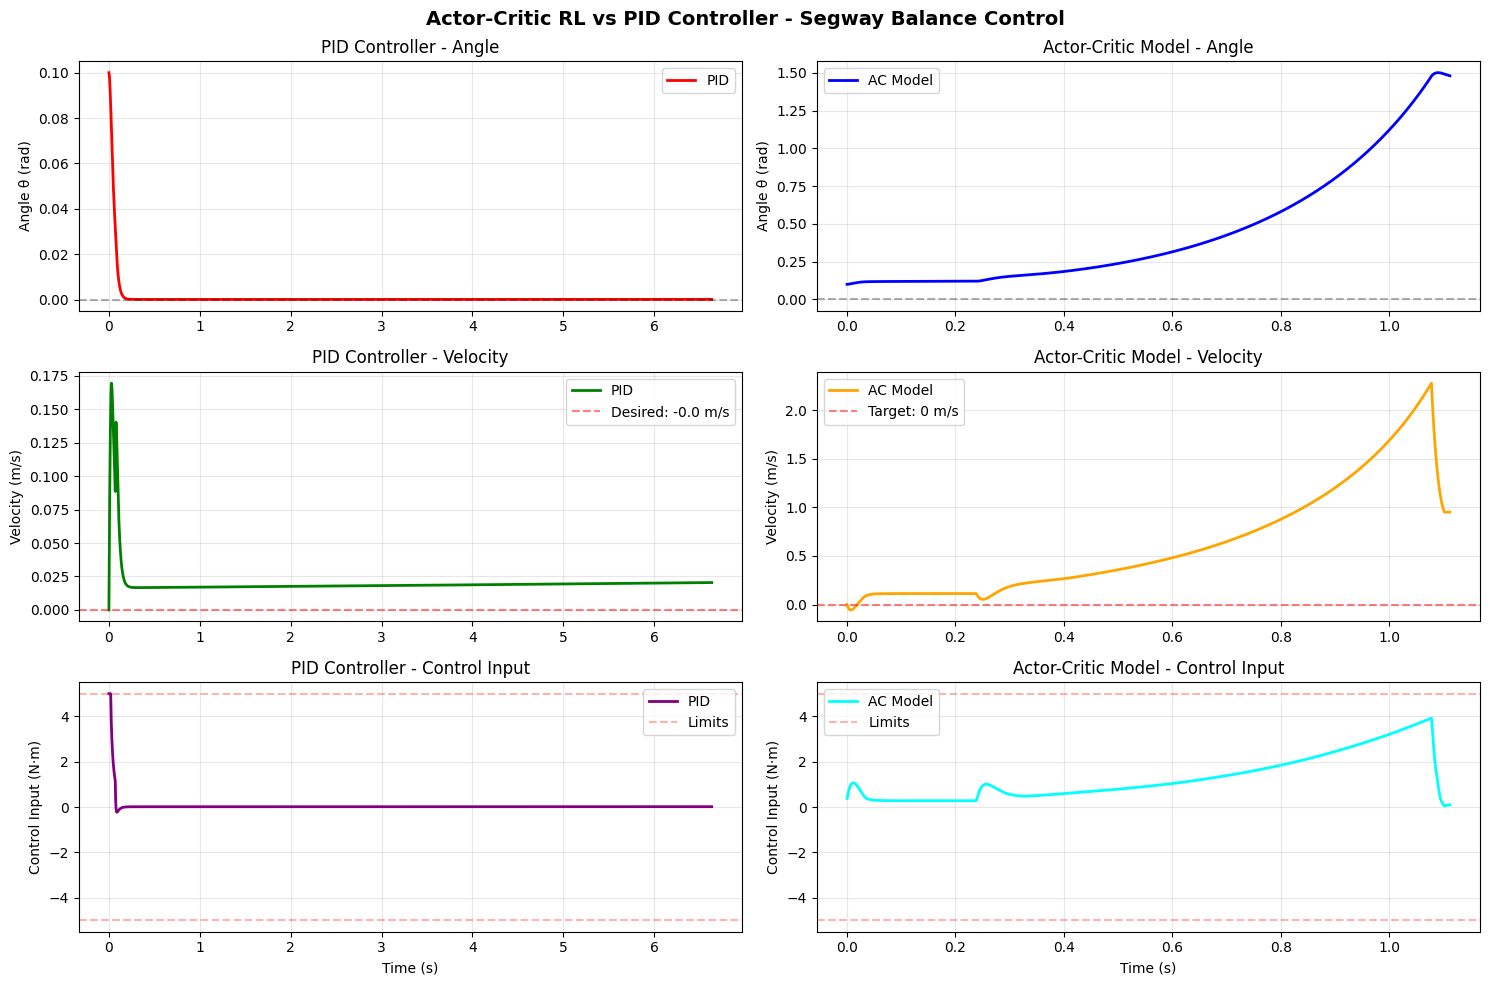


COMPARATIVE PERFORMANCE ANALYSIS

Metric                         PID Controller       Actor-Critic        
----------------------------------------------------------------------
Mean angle error (rad)         0.0009               0.4530              
Max angle deviation (rad)      0.1000               1.5009              
Mean control effort (N·m)      0.05                 1.28                
Max control action (N·m)       5.00                 3.92                
Final position (m)             0.135                0.700               
Final velocity (m/s)           0.020                0.950               
Mean reward                    N/A                  0.5187              
----------------------------------------------------------------------

Performance Assessment:
✗ PID controller achieves better angle stability
✗ PID controller uses less control effort

Notes:
- Actor-Critic learns directly from interaction with the environment
- PID uses hand-tuned parameters (Kp, Ki, Kd)


In [37]:
# ============ COMPARISON: ACTOR-CRITIC vs PID CONTROLLER ============
# Side-by-side visualization of RL model vs traditional PID controller

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Actor-Critic RL vs PID Controller - Segway Balance Control', fontsize=14, fontweight='bold')

# Column 0: PID Controller, Column 1: Actor-Critic Model

# Plot 1: Angle Comparison
axes[0, 0].plot(times, angles, 'r-', linewidth=2, label='PID')
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].set_ylabel('Angle θ (rad)')
axes[0, 0].set_title('PID Controller - Angle')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(eval_times, eval_angles, 'b-', linewidth=2, label='AC Model')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_ylabel('Angle θ (rad)')
axes[0, 1].set_title('Actor-Critic Model - Angle')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 2: Velocity Comparison
axes[1, 0].plot(times, x_velocities, 'g-', linewidth=2, label='PID')
axes[1, 0].axhline(y=v_desired, color='r', linestyle='--', alpha=0.5, label=f'Desired: {v_desired} m/s')
axes[1, 0].set_ylabel('Velocity (m/s)')
axes[1, 0].set_title('PID Controller - Velocity')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(eval_times, eval_x_velocities, 'orange', linewidth=2, label='AC Model')
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Target: 0 m/s')
axes[1, 1].set_ylabel('Velocity (m/s)')
axes[1, 1].set_title('Actor-Critic Model - Velocity')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Plot 3: Control Input Comparison
axes[2, 0].plot(times, control_inputs_total, 'purple', linewidth=2, label='PID')
axes[2, 0].axhline(y=5.0, color='r', linestyle='--', alpha=0.3, label='Limits')
axes[2, 0].axhline(y=-5.0, color='r', linestyle='--', alpha=0.3)
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Control Input (N·m)')
axes[2, 0].set_title('PID Controller - Control Input')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

axes[2, 1].plot(eval_times, eval_actions, 'cyan', linewidth=2, label='AC Model')
axes[2, 1].axhline(y=5.0, color='r', linestyle='--', alpha=0.3, label='Limits')
axes[2, 1].axhline(y=-5.0, color='r', linestyle='--', alpha=0.3)
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Control Input (N·m)')
axes[2, 1].set_title('Actor-Critic Model - Control Input')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

# Comparative Performance Summary
print("\n" + "=" * 70)
print("COMPARATIVE PERFORMANCE ANALYSIS")
print("=" * 70)

pid_angle_error = np.mean(np.abs(np.array(angles)))
ac_angle_error = np.mean(np.abs(np.array(eval_angles)))

pid_control_avg = np.mean(np.abs(np.array(control_inputs_total)))
ac_control_avg = np.mean(np.abs(np.array(eval_actions)))

pid_max_angle = max(abs(a) for a in angles)
ac_max_angle = max(abs(a) for a in eval_angles)

print(f"\n{'Metric':<30} {'PID Controller':<20} {'Actor-Critic':<20}")
print("-" * 70)
print(f"{'Mean angle error (rad)':<30} {pid_angle_error:<20.4f} {ac_angle_error:<20.4f}")
print(f"{'Max angle deviation (rad)':<30} {pid_max_angle:<20.4f} {ac_max_angle:<20.4f}")
print(f"{'Mean control effort (N·m)':<30} {pid_control_avg:<20.2f} {ac_control_avg:<20.2f}")
print(f"{'Max control action (N·m)':<30} {max(abs(u) for u in control_inputs_total):<20.2f} {max(abs(a) for a in eval_actions):<20.2f}")
print(f"{'Final position (m)':<30} {x_positions[-1]:<20.3f} {eval_x_positions[-1]:<20.3f}")
print(f"{'Final velocity (m/s)':<30} {x_velocities[-1]:<20.3f} {eval_x_velocities[-1]:<20.3f}")
print(f"{'Mean reward':<30} {'N/A':<20} {np.mean(eval_rewards):<20.4f}")
print("-" * 70)

# Performance verdict
print("\nPerformance Assessment:")
if ac_angle_error < pid_angle_error:
    improvement = ((pid_angle_error - ac_angle_error) / pid_angle_error) * 100
    print(f"✓ Actor-Critic achieves {improvement:.1f}% better angle stability")
else:
    print(f"✗ PID controller achieves better angle stability")

if ac_control_avg < pid_control_avg:
    efficiency = ((pid_control_avg - ac_control_avg) / pid_control_avg) * 100
    print(f"✓ Actor-Critic uses {efficiency:.1f}% less control effort")
else:
    print(f"✗ PID controller uses less control effort")

print("\nNotes:")
print("- Actor-Critic learns directly from interaction with the environment")
print("- PID uses hand-tuned parameters (Kp, Ki, Kd)")
print("- RL model can adapt to different initial conditions and disturbances")
print("- With more training, AC performance typically improves further")


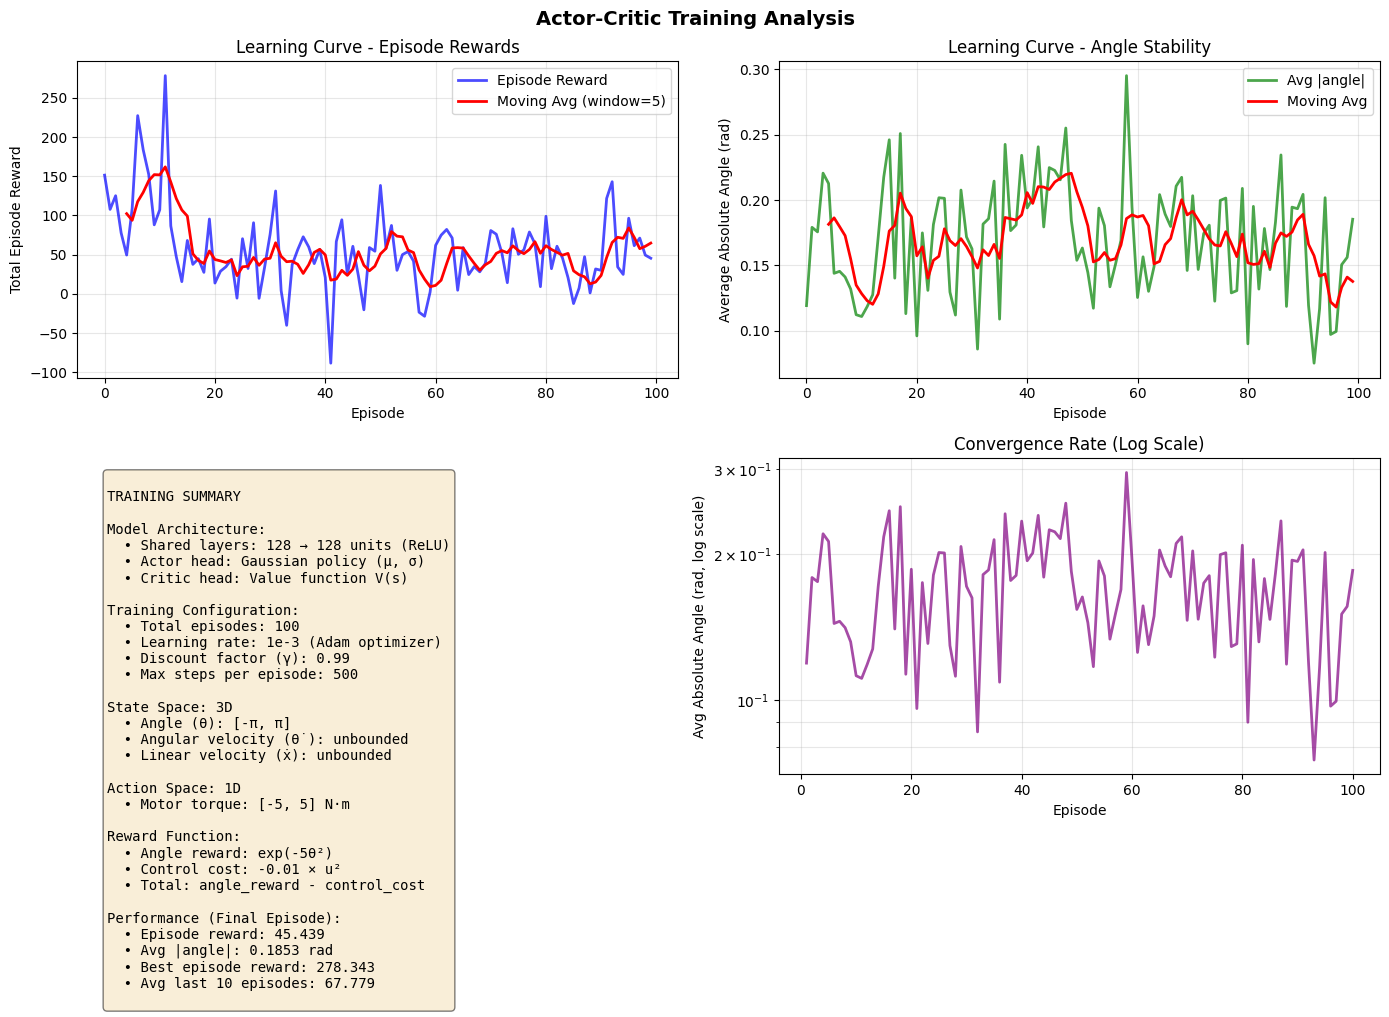


DETAILED TRAINING STATISTICS

Reward Statistics:
  Mean: 56.711
  Std Dev: 51.539
  Min: -88.414 (Episode 42)
  Max: 278.343 (Episode 12)
  Final: 45.439

Angle Stability (Mean Absolute Angle):
  Mean: 0.1694 rad
  Std Dev: 0.0435 rad
  Min: 0.0752 rad
  Max: 0.2952 rad
  Final: 0.1853 rad

Convergence Analysis:
  Avg angle (episodes 1-10): 0.1582 rad
  Avg angle (episodes 91-100): 0.1406 rad
  Improvement: 11.1%

MODEL READY FOR EVALUATION ON NEW CONDITIONS

You can now:
1. Test with different initial angles
2. Add disturbances during evaluation
3. Compare with other control methods
4. Fine-tune hyperparameters for better performance


In [38]:
# ============ TRAINING ANALYSIS & LEARNING CURVES ============
# Analyze the learning process and model robustness

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Actor-Critic Training Analysis', fontsize=14, fontweight='bold')

# Plot 1: Episode Rewards
axes[0, 0].plot(episode_rewards, 'b-', linewidth=2, alpha=0.7, label='Episode Reward')
# Add moving average
window = 5
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(range(window-1, len(episode_rewards)), moving_avg, 'r-', linewidth=2, label=f'Moving Avg (window={window})')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Episode Reward')
axes[0, 0].set_title('Learning Curve - Episode Rewards')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Average Angle Error per Episode
axes[0, 1].plot(episode_avg_angles, 'g-', linewidth=2, alpha=0.7, label='Avg |angle|')
moving_avg_angles = np.convolve(episode_avg_angles, np.ones(window)/window, mode='valid')
axes[0, 1].plot(range(window-1, len(episode_avg_angles)), moving_avg_angles, 'r-', linewidth=2, label=f'Moving Avg')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Average Absolute Angle (rad)')
axes[0, 1].set_title('Learning Curve - Angle Stability')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Training Metrics Summary
axes[1, 0].axis('off')
summary_text = f"""
TRAINING SUMMARY

Model Architecture:
  • Shared layers: 128 → 128 units (ReLU)
  • Actor head: Gaussian policy (μ, σ)
  • Critic head: Value function V(s)
  
Training Configuration:
  • Total episodes: {num_episodes}
  • Learning rate: 1e-3 (Adam optimizer)
  • Discount factor (γ): 0.99
  • Max steps per episode: 500
  
State Space: 3D
  • Angle (θ): [-π, π]
  • Angular velocity (θ̇): unbounded
  • Linear velocity (ẋ): unbounded

Action Space: 1D
  • Motor torque: [-5, 5] N·m
  
Reward Function:
  • Angle reward: exp(-5θ²)
  • Control cost: -0.01 × u²
  • Total: angle_reward - control_cost

Performance (Final Episode):
  • Episode reward: {episode_rewards[-1]:.3f}
  • Avg |angle|: {episode_avg_angles[-1]:.4f} rad
  • Best episode reward: {max(episode_rewards):.3f}
  • Avg last 10 episodes: {np.mean(episode_rewards[-10:]):.3f}
"""
axes[1, 0].text(0.05, 0.95, summary_text, transform=axes[1, 0].transAxes, 
                fontfamily='monospace', fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Convergence Rate
axes[1, 1].semilogy(range(1, len(episode_rewards)+1), np.abs(np.array(episode_avg_angles)), 'purple', linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Avg Absolute Angle (rad, log scale)')
axes[1, 1].set_title('Convergence Rate (Log Scale)')
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Training Statistics
print("\n" + "=" * 70)
print("DETAILED TRAINING STATISTICS")
print("=" * 70)

best_episode = np.argmax(episode_rewards) + 1
worst_episode = np.argmin(episode_rewards) + 1

print(f"\nReward Statistics:")
print(f"  Mean: {np.mean(episode_rewards):.3f}")
print(f"  Std Dev: {np.std(episode_rewards):.3f}")
print(f"  Min: {np.min(episode_rewards):.3f} (Episode {worst_episode})")
print(f"  Max: {np.max(episode_rewards):.3f} (Episode {best_episode})")
print(f"  Final: {episode_rewards[-1]:.3f}")

print(f"\nAngle Stability (Mean Absolute Angle):")
print(f"  Mean: {np.mean(episode_avg_angles):.4f} rad")
print(f"  Std Dev: {np.std(episode_avg_angles):.4f} rad")
print(f"  Min: {np.min(episode_avg_angles):.4f} rad")
print(f"  Max: {np.max(episode_avg_angles):.4f} rad")
print(f"  Final: {episode_avg_angles[-1]:.4f} rad")

# Convergence analysis
first_10_avg = np.mean(episode_avg_angles[:10])
last_10_avg = np.mean(episode_avg_angles[-10:])
improvement = ((first_10_avg - last_10_avg) / first_10_avg) * 100 if first_10_avg > 0 else 0

print(f"\nConvergence Analysis:")
print(f"  Avg angle (episodes 1-10): {first_10_avg:.4f} rad")
print(f"  Avg angle (episodes {num_episodes-9}-{num_episodes}): {last_10_avg:.4f} rad")
print(f"  Improvement: {improvement:.1f}%")

print("\n" + "=" * 70)
print("MODEL READY FOR EVALUATION ON NEW CONDITIONS")
print("=" * 70)
print("\nYou can now:")
print("1. Test with different initial angles")
print("2. Add disturbances during evaluation")
print("3. Compare with other control methods")
print("4. Fine-tune hyperparameters for better performance")
